# 04 — Failure Case Study

Deep dive into the failure events recorded in `app/storage/analytics/failures.jsonl`. Examines top failure modes and proposes targeted fixes.

In [1]:
import json
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if (REPO_ROOT / 'app').exists() is False:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from app.analytics.failure_analyzer import build_failure_report, render_markdown_report, load_failures
FAILURES = REPO_ROOT / 'app/storage/analytics/failures.jsonl'
print('Failures file exists:', FAILURES.exists())

Failures file exists: True


## 1. Overview

In [2]:
report = build_failure_report(FAILURES)
print(f'Total failures: {report["total_failures"]}')
print('Top modes:', report['top_failure_modes'])

Total failures: 10
Top modes: [('qa_low_score', 8), ('qa_bad_citation', 1), ('qa_empty_answer', 1)]


## 2. Failure type distribution (pie chart)

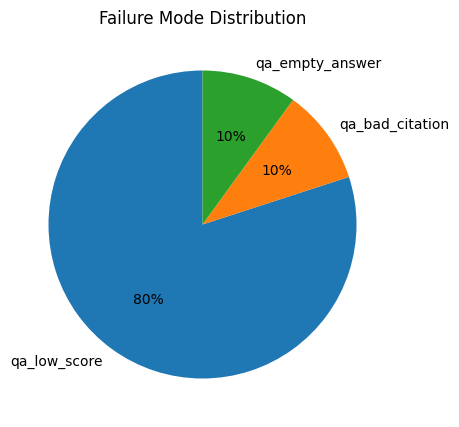

In [3]:
import matplotlib.pyplot as plt
modes = report['top_failure_modes']
if modes:
    labels = [m for m, _ in modes]
    sizes = [c for _, c in modes]
    fig, ax = plt.subplots(figsize=(6,5))
    ax.pie(sizes, labels=labels, autopct='%1.0f%%', startangle=90)
    ax.set_title('Failure Mode Distribution')
    fig
else:
    print('No failures recorded; run pipeline to populate.')

## 3. Per-category breakdown

In [4]:
for section in ('retrieval', 'qa', 'comparison'):
    print(f'\n=== {section.upper()} ===')
    print(json.dumps(report.get(section, {}), ensure_ascii=False, indent=2))


=== RETRIEVAL ===
{
  "total": 0,
  "sub_type_counts": {},
  "by_paper": {},
  "top_query_words": []
}

=== QA ===
{
  "total": 10,
  "sub_type_counts": {
    "qa_bad_citation": 1,
    "qa_low_score": 8,
    "qa_empty_answer": 1
  },
  "empty_answer_count": 2,
  "long_answer_count": 0,
  "top_failing_samples": [
    [
      "paper_20260509_004-abstract",
      1
    ],
    [
      "paper_20260509_004-section-1-v1",
      1
    ],
    [
      "paper_20260511_002-abstract",
      1
    ],
    [
      "paper_20260511_002-section-1-v1",
      1
    ],
    [
      "paper_20260511_004-abstract",
      1
    ],
    [
      "paper_20260511_004-section-1-v1",
      1
    ],
    [
      "paper_20260511_005-abstract",
      1
    ],
    [
      "paper_20260511_005-section-1-v1",
      1
    ],
    [
      "paper_20260509_004-hard-oos",
      1
    ],
    [
      "paper_20260511_002-hard-oos",
      1
    ]
  ]
}

=== COMPARISON ===
{
  "total": 0,
  "sub_type_counts": {}
}


## 4. Raw failure cases (full payloads)

In [5]:
cases = load_failures(FAILURES)
for case in cases[:10]:
    print(json.dumps(case, ensure_ascii=False, indent=2))

{
  "event_type": "failure",
  "timestamp": "2026-05-20T12:22:07.827449+00:00",
  "payload": {
    "failure_type": "qa_bad_citation",
    "reason": "citation score 0.000 below threshold",
    "context": {
      "sample_id": "paper_20260509_004-abstract",
      "question": "What does the paper 'Receptive-Field and Direction Induced Attention' mainly propose or study?",
      "citation_score": 0.0
    }
  }
}
{
  "event_type": "failure",
  "timestamp": "2026-05-20T12:22:24.549907+00:00",
  "payload": {
    "failure_type": "qa_low_score",
    "reason": "answer score 0.111 below threshold 0.5",
    "context": {
      "sample_id": "paper_20260509_004-section-1-v1",
      "question": "According to the 'results' section of 'Receptive-Field and Direction Induced Attention', what key information is highlighted?",
      "score": 0.1111111111111111,
      "answer": "根据当前提供的论文片段，**无法直接从“results”章节判断其“highlighted key information”具体是什么**，因为检索结果中**没有给出 results 章节的完整表述**，仅有少量与实验设置和图示相关的内容。\n\n不过，从现有片段

## 5. Auto-generated markdown report

In [6]:
from IPython.display import Markdown
Markdown(render_markdown_report(report))

# Failure Analysis Report

**Total failures**: 10

## Top Failure Modes

| Failure Type | Count |
|---|---|
| qa_low_score | 8 |
| qa_bad_citation | 1 |
| qa_empty_answer | 1 |

## Retrieval Failures

_None recorded._

## QA Failures

- Total: **10**
- Sub-types:
  - qa_bad_citation: 1
  - qa_low_score: 8
  - qa_empty_answer: 1
- Empty-answer failures: 2
- Long-answer failures (>800 chars): 0

## Comparison Failures

_None recorded._

## Optimization Suggestions

- Audit LLM error handling — empty answers often hide silent client closures.
- Tighten the QA prompt with explicit citation requirements and few-shot exemplars.
- Improve citation post-processing — verify each cited section actually appears in the retrieved chunks.

## 6. Recommended fixes

1. **retrieval_no_results / retrieval_low_score** — try hybrid (BM25 + dense) and Phase 4 reranker.
2. **qa_empty_answer** — audit LLM client closure handling (already retries once in `paper_qa.py`).
3. **qa_low_score** — tighten the QA prompt with explicit citation requirements + few-shot examples.
4. **comparison_incomplete** — feed structured per-paper summaries (already implemented) and validate aspect coverage at parse time.